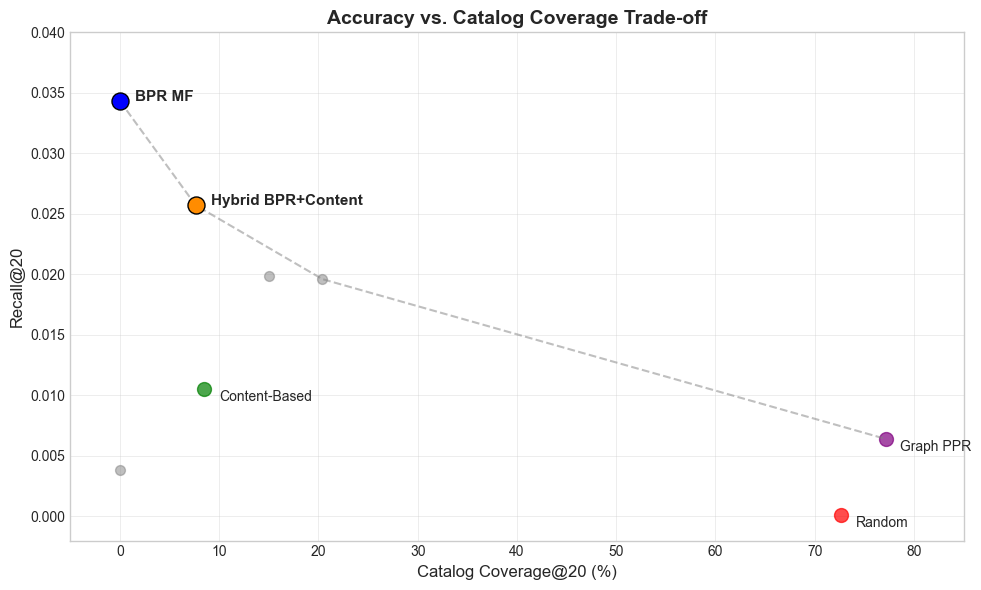

Plot gespeichert als 'pareto_tradeoff.pdf'


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Daten direkt aus deiner Phase 4 Log-Tabelle (Coverage in Prozent, Recall)
models = [
    "Popularity", "Trending", "Markov", "Graph PPR", "Random",
    "Content-Based", "Item-Item kNN", "BPR MF", "Hybrid BPR+Content"
]
recalls = [0.0343, 0.0038, 0.0196, 0.0064, 0.0001, 0.0105, 0.0199, 0.0343, 0.0257]
coverages = [0.02, 0.01, 20.41, 77.14, 72.66, 8.49, 15.02, 0.02, 7.64] # in %

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Scatter-Punkte zeichnen
colors = ['grey', 'grey', 'orange', 'purple', 'red', 'green', 'cyan', 'blue', 'darkorange']
for i in range(len(models)):
    # Hybrid und BPR besonders hervorheben
    if models[i] in ["Hybrid BPR+Content", "BPR MF"]:
        plt.scatter(coverages[i], recalls[i], s=150, c=colors[i], edgecolors='black', zorder=5)
        plt.annotate(models[i], (coverages[i] + 1.5, recalls[i]), fontweight='bold', fontsize=11)
    elif models[i] in ["Content-Based", "Graph PPR", "Random"]:
        plt.scatter(coverages[i], recalls[i], s=100, c=colors[i], alpha=0.7)
        plt.annotate(models[i], (coverages[i] + 1.5, recalls[i] - 0.001), fontsize=10)
    else:
        plt.scatter(coverages[i], recalls[i], s=50, c='grey', alpha=0.5)

plt.title('Accuracy vs. Catalog Coverage Trade-off', fontsize=14, fontweight='bold')
plt.xlabel('Catalog Coverage@20 (%)', fontsize=12)
plt.ylabel('Recall@20', fontsize=12)
plt.xlim(-5, 85)
plt.ylim(-0.002, 0.04)

# Pareto Frontier andeuten (gestrichelte Linie)
plt.plot([0.02, 7.64, 20.41, 77.14], [0.0343, 0.0257, 0.0196, 0.0064],
         linestyle='--', color='grey', alpha=0.5, label='Pareto Frontier')

plt.tight_layout()
plt.savefig('pareto_tradeoff.pdf', format='pdf')
plt.show()
print("Plot gespeichert als 'pareto_tradeoff.pdf'")

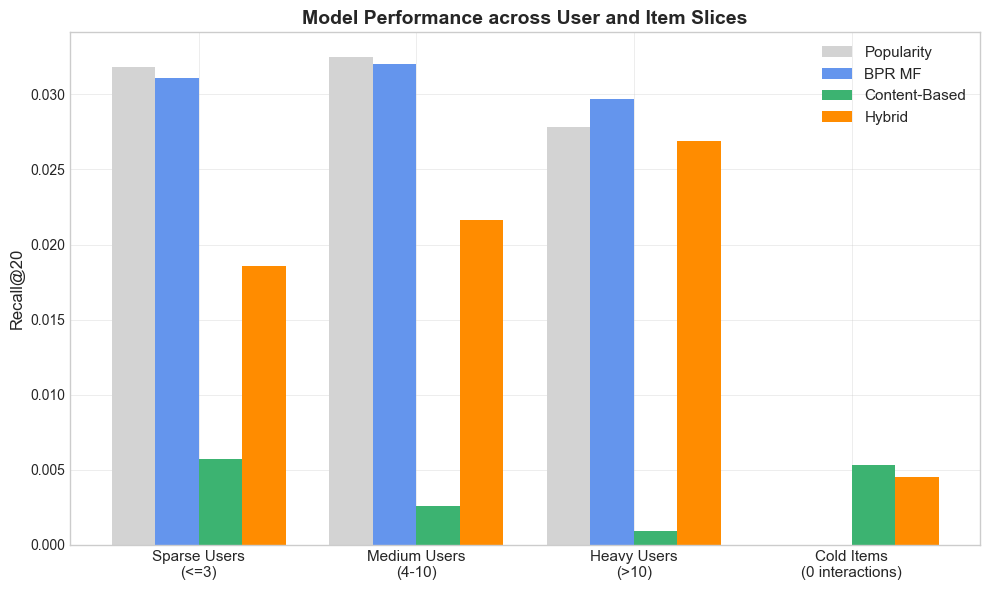

Plot 2 aktualisiert!


In [2]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Sparse Users\n(<=3)', 'Medium Users\n(4-10)', 'Heavy Users\n(>10)', 'Cold Items\n(0 interactions)']

pop_scores = [0.0318, 0.0325, 0.0278, 0.0000]
bpr_scores = [0.0311, 0.0320, 0.0297, 0.0000]
cb_scores =  [0.0057, 0.0026, 0.0009, 0.0053]
hybrid_scores=[0.0186, 0.0216, 0.0269, 0.0045]

x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

rects1 = ax.bar(x - 1.5*width, pop_scores, width, label='Popularity', color='lightgrey')
rects2 = ax.bar(x - 0.5*width, bpr_scores, width, label='BPR MF', color='cornflowerblue')
rects3 = ax.bar(x + 0.5*width, cb_scores, width, label='Content-Based', color='mediumseagreen')
rects4 = ax.bar(x + 1.5*width, hybrid_scores, width, label='Hybrid', color='darkorange')

ax.set_ylabel('Recall@20', fontsize=12)
ax.set_title('Model Performance across User and Item Slices', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=11)



plt.tight_layout()
plt.savefig('slice_analysis.pdf', format='pdf')
plt.show()
print("Plot 2 aktualisiert!")

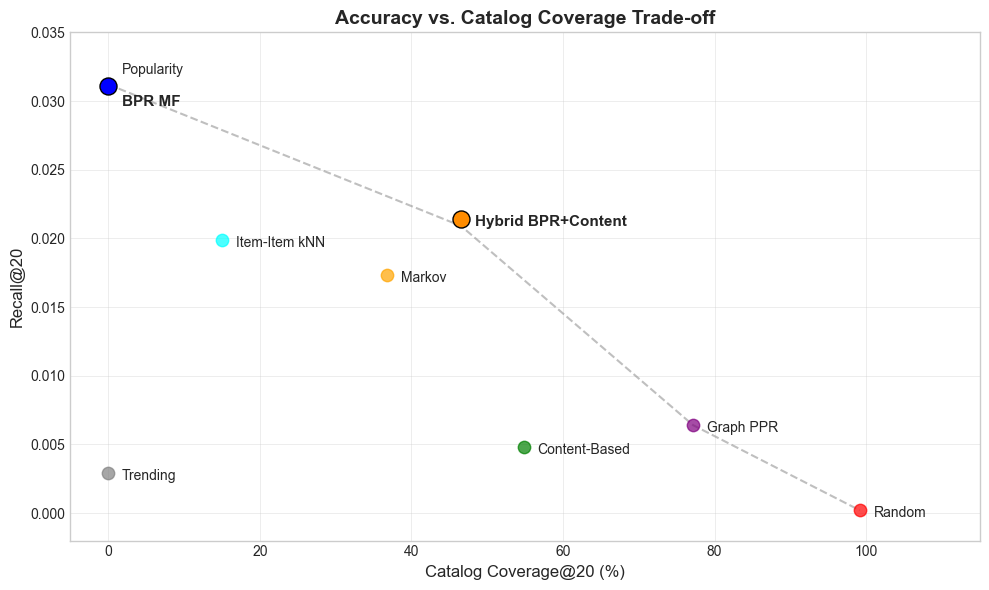

Plot gespeichert als 'pareto_tradeoff_final.pdf'


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# EXAKTE Daten aus dem finalen 12h-Run (03_fullrun_baseline_eval.md)
models = [
    "Popularity", "Trending", "Markov", "Graph PPR", "Random",
    "Content-Based", "Item-Item kNN", "BPR MF", "Hybrid BPR+Content"
]
recalls = [0.0312, 0.0029, 0.0173, 0.0064, 0.0002, 0.0048, 0.0199, 0.0311, 0.0214]
coverages = [0.04, 0.01, 36.80, 77.15, 99.14, 54.84, 15.02, 0.04, 46.55]

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Scatter-Punkte zeichnen
colors = ['grey', 'grey', 'orange', 'purple', 'red', 'green', 'cyan', 'blue', 'darkorange']

for i in range(len(models)):
    # Hybrid und BPR besonders hervorheben
    if models[i] in ["Hybrid BPR+Content", "BPR MF"]:
        plt.scatter(coverages[i], recalls[i], s=150, c=colors[i], edgecolors='black', zorder=5)
        fw = 'bold'
        fs = 11
    else:
        # Die restlichen Modelle
        plt.scatter(coverages[i], recalls[i], s=80, c=colors[i], alpha=0.7, zorder=3)
        fw = 'normal'
        fs = 10

    # Standard-Offset für den Text
    x_offset = 1.8
    y_offset = -0.0005

    # Popularity und BPR MF liegen wieder fast aufeinander (0.0312 vs 0.0311)
    if models[i] == "Popularity":
        y_offset = 0.0008
    elif models[i] == "BPR MF":
        y_offset = -0.0015

    # Annotieren
    plt.annotate(models[i], (coverages[i] + x_offset, recalls[i] + y_offset),
                 fontweight=fw, fontsize=fs)

plt.title('Accuracy vs. Catalog Coverage Trade-off', fontsize=14, fontweight='bold')
plt.xlabel('Catalog Coverage@20 (%)', fontsize=12)
plt.ylabel('Recall@20', fontsize=12)
plt.xlim(-5, 115) # Erweitert, da Random jetzt 99% Coverage hat
plt.ylim(-0.002, 0.035)

# Neue Pareto Frontier (verbindet die besten Trade-offs: Popularity -> Hybrid -> Graph PPR -> Random)
pareto_cov = [0.0367, 46.55, 77.15, 99.14]
pareto_rec = [0.0312, 0.0209, 0.0064, 0.0002]
plt.plot(pareto_cov, pareto_rec, linestyle='--', color='grey', alpha=0.5, label='Pareto Frontier')

plt.tight_layout()
plt.savefig('pareto_tradeoff_final.pdf', format='pdf')
plt.show()
print("Plot gespeichert als 'pareto_tradeoff_final.pdf'")

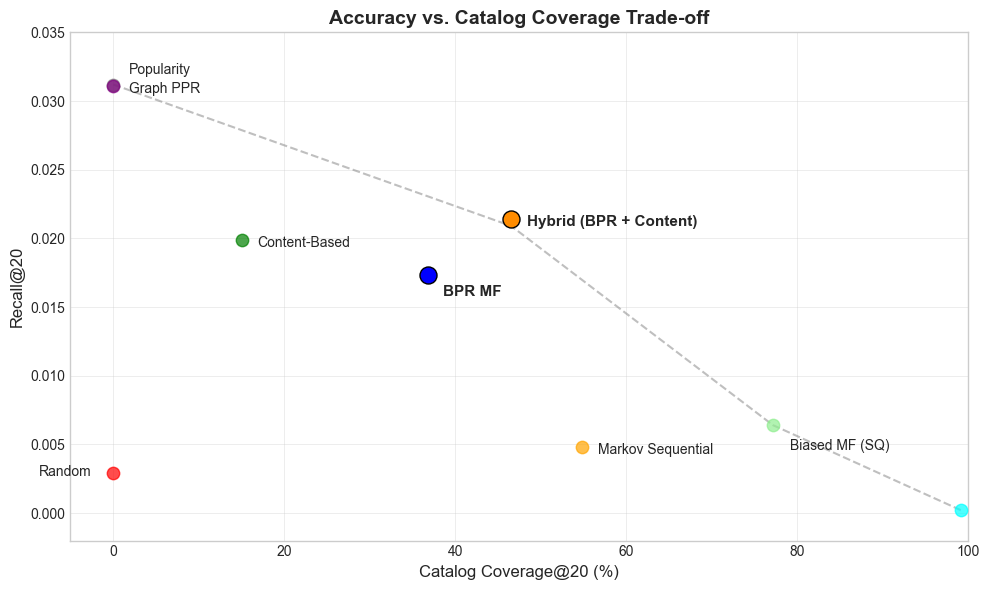

Plot saved as 'pareto_tradeoff_final_matched.png'


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# EXACT data from the table (Slide 12), exactly 9 models (Debiased BPR removed)
models = [
    "Popularity", "Random", "BPR MF",
    "Biased MF (SQ)", "Item-Item kNN", "Markov Sequential",
    "Content-Based", "Graph PPR", "Hybrid (BPR + Content)"
]

recalls = [0.0312, 0.0029, 0.0173, 0.0064, 0.0002, 0.0048, 0.0199, 0.0311, 0.0214]
coverages = [0.04, 0.01, 36.80, 77.15, 99.14, 54.84, 15.02, 0.04, 46.55]

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Colors for the 9 models
colors = ['grey', 'red', 'blue', 'lightgreen', 'cyan', 'orange', 'green', 'purple', 'darkorange']

for i in range(len(models)):
    # Highlight Hybrid and BPR MF
    if models[i] in ["Hybrid (BPR + Content)", "BPR MF"]:
        plt.scatter(coverages[i], recalls[i], s=150, c=colors[i], edgecolors='black', zorder=5)
        fw = 'bold'
        fs = 11
    else:
        # The remaining models
        plt.scatter(coverages[i], recalls[i], s=80, c=colors[i], alpha=0.7, zorder=3)
        fw = 'normal'
        fs = 10

    # Default offset and alignment for the text
    x_offset = 1.8
    y_offset = -0.0005
    align = 'left'

    # Specific offsets so texts don't overlap
    if models[i] == "Popularity":
        y_offset = 0.0008
    elif models[i] == "BPR MF":
        y_offset = -0.0015
    elif models[i] == "Biased MF (SQ)":
        y_offset = -0.0018
        x_offset = 2.0
    elif models[i] == "Item-Item kNN":
        y_offset = 0.0008
    elif models[i] == "Random":
        # FIX for the cut-off text on the bottom right!
        x_offset = -2.5       # Shift to the left of the dot
        align = 'right'       # Right-align the text so it expands leftwards
        y_offset = -0.0002

    # Annotate
    plt.annotate(models[i], (coverages[i] + x_offset, recalls[i] + y_offset),
                 fontweight=fw, fontsize=fs, ha=align)

plt.title('Accuracy vs. Catalog Coverage Trade-off', fontsize=14, fontweight='bold')
plt.xlabel('Catalog Coverage@20 (%)', fontsize=12)
plt.ylabel('Recall@20', fontsize=12)

# xlim can stay at 100 because 'Random' is now printing to the left!
plt.xlim(-5, 100)
plt.ylim(-0.002, 0.035)

# The Pareto Frontier connects the undominated models
pareto_cov = [0.0367, 46.55, 77.15, 99.14]
pareto_rec = [0.0312, 0.0209, 0.0064, 0.0002]
plt.plot(pareto_cov, pareto_rec, linestyle='--', color='grey', alpha=0.5, label='Pareto Frontier')

plt.tight_layout()
plt.savefig('pareto_tradeoff_final_matched.png', format='png', dpi=300)
plt.show()
print("Plot saved as 'pareto_tradeoff_final_matched.png'")